In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Optional (install if needed)
# pip install wordcloud
from wordcloud import WordCloud

In [2]:
DATASET_PATH = "../data/generated/customer_support_dataset.csv"

df = pd.read_csv(DATASET_PATH)

df.head()

,customer_name,customer_email,customer_type,country,channel,product,ticket_id,subject,description,category,priority,sentiment,assigned_team,status
0,Clinton Nichols,alexanderharmon@example.org,Enterprise,Canada,Chat,API Platform,TKT-DD82610CA0,Organization details incorrect,I have been trying to access my account since ...,Account,Medium,Negative,Account Support Team,Open
1,Michael Lopez,matthew78@example.org,Premium,Canada,Phone,Web Dashboard,TKT-132439D31D,Reset code invalid,I have been trying to access my account since ...,Password Reset,Medium,Negative,Authentication Team,Open
2,Megan Garcia,brookserika@example.org,Enterprise,Brazil,Website,Reporting Engine,TKT-0B7E32F4C9,Business profile issue,I have been trying to access my account since ...,Account,Low,Neutral,Account Support Team,Open
3,Debra Garcia,kathryn26@example.org,Enterprise,India,Mobile App,Web Dashboard,TKT-F837AEB837,Login failed,I have been trying to access my account since ...,Login,Medium,Negative,Authentication Team,Open
4,Kristen Morris,veronicagonzales@example.net,Free,United Kingdom,Mobile App,CRM Suite,TKT-604F417304,Password reset page not working,I have been trying to access my account since ...,Password Reset,Medium,Neutral,Authentication Team,Open


In [3]:
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print()

df.info()

DATASET INFORMATION
Rows: 1000
Columns: 14

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_name   1000 non-null   object
 1   customer_email  1000 non-null   object
 2   customer_type   1000 non-null   object
 3   country         1000 non-null   object
 4   channel         1000 non-null   object
 5   product         1000 non-null   object
 6   ticket_id       1000 non-null   object
 7   subject         1000 non-null   object
 8   description     1000 non-null   object
 9   category        1000 non-null   object
 10  priority        1000 non-null   object
 11  sentiment       1000 non-null   object
 12  assigned_team   1000 non-null   object
 13  status          1000 non-null   object
dtypes: object(14)
memory usage: 109.5+ KB


In [4]:
df.describe(include="all")

,customer_name,customer_email,customer_type,country,channel,product,ticket_id,subject,description,category,priority,sentiment,assigned_team,status
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,991,1000,4,10,5,8,1000,30,1000,3,3,2,2,1
top,James Miller,alexanderharmon@example.org,Free,United Kingdom,Mobile App,CRM Suite,TKT-DD82610CA0,Password reset page not working,I have been trying to access my account since ...,Password Reset,Medium,Negative,Authentication Team,Open
freq,2,1,270,117,229,145,1,50,1,350,490,662,690,1000


In [5]:
missing = df.isnull().sum()

missing

customer_name     0
customer_email    0
customer_type     0
country           0
channel           0
product           0
ticket_id         0
subject           0
description       0
category          0
priority          0
sentiment         0
assigned_team     0
status            0
dtype: int64

In [6]:
print("Duplicate Rows")

print(df.duplicated().sum())

Duplicate Rows
0


category
Password Reset    350
Login             340
Account           310
Name: count, dtype: int64


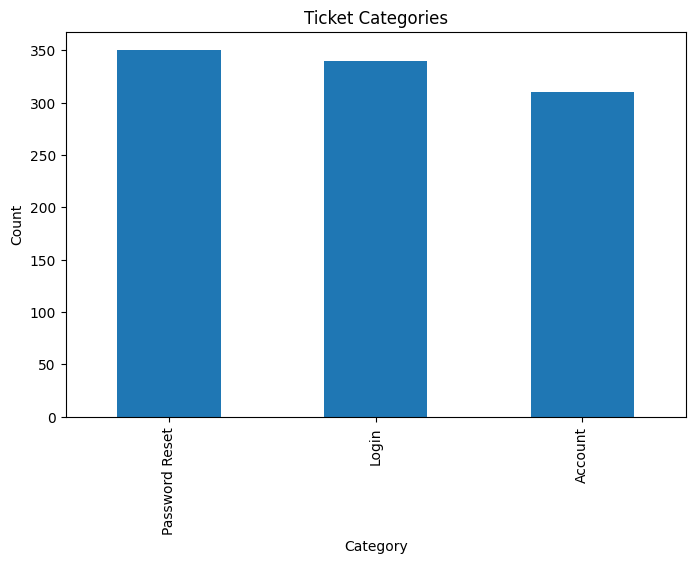

In [7]:
category_counts = df["category"].value_counts()

print(category_counts)

category_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Ticket Categories")

plt.xlabel("Category")

plt.ylabel("Count")

plt.show()

priority
Medium    490
Low       339
High      171
Name: count, dtype: int64


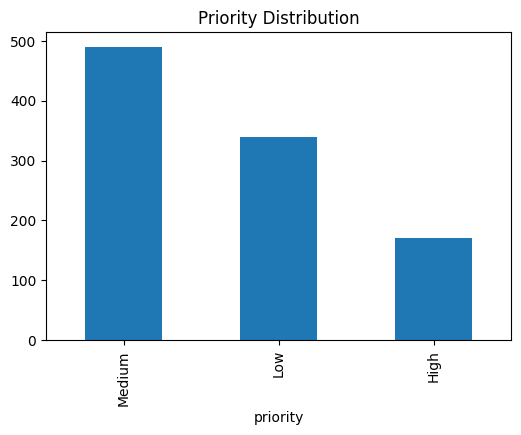

In [8]:
priority = df["priority"].value_counts()

print(priority)

priority.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Priority Distribution")

plt.show()

sentiment
Negative    662
Neutral     338
Name: count, dtype: int64


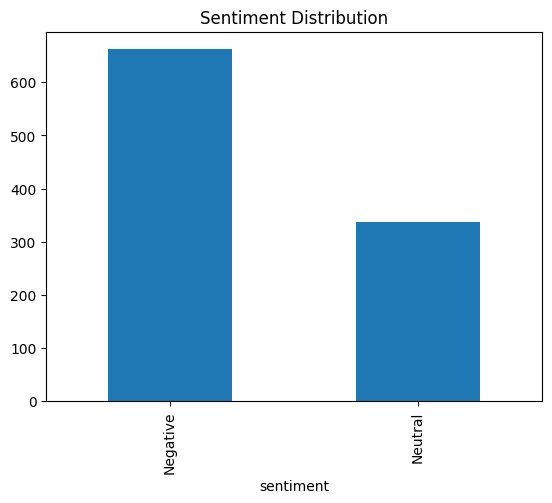

In [9]:
sentiment = df["sentiment"].value_counts()

print(sentiment)

sentiment.plot(kind="bar")

plt.title("Sentiment Distribution")

plt.show()

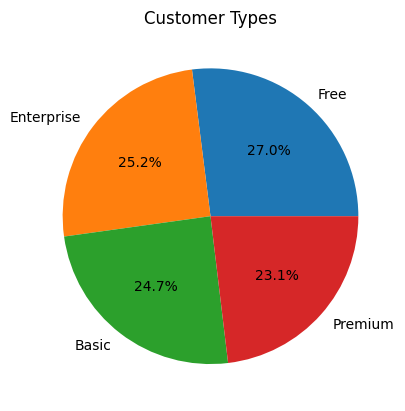

In [10]:
customer = df["customer_type"].value_counts()

customer.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")

plt.title("Customer Types")

plt.show()

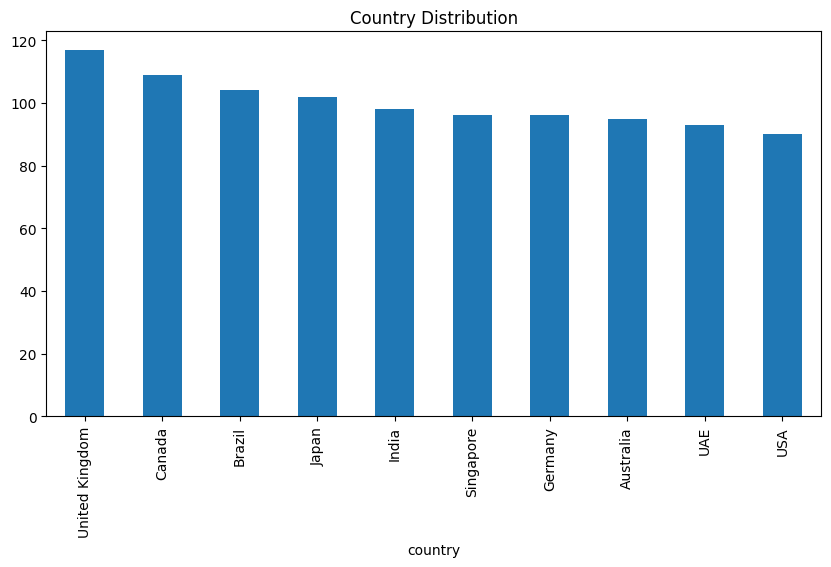

In [11]:
country = df["country"].value_counts()

country.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Country Distribution")

plt.show()

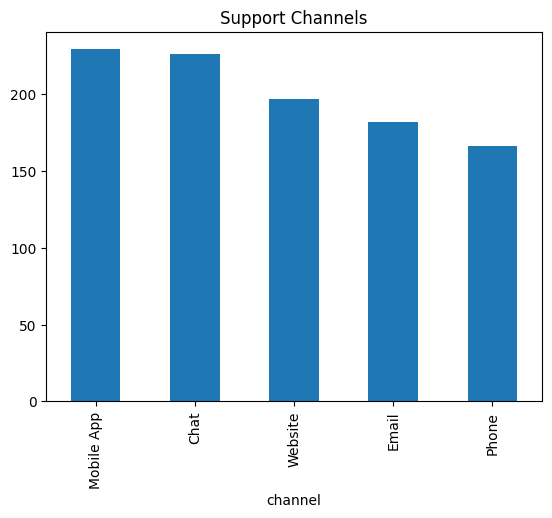

In [12]:
channel = df["channel"].value_counts()

channel.plot(kind="bar")

plt.title("Support Channels")

plt.show()

In [13]:
df["description_length"] = df["description"].str.len()

df["description_length"].describe()

count    1000.000000
mean      283.954000
std        11.791137
min       248.000000
25%       275.000000
50%       283.000000
75%       292.000000
max       316.000000
Name: description_length, dtype: float64

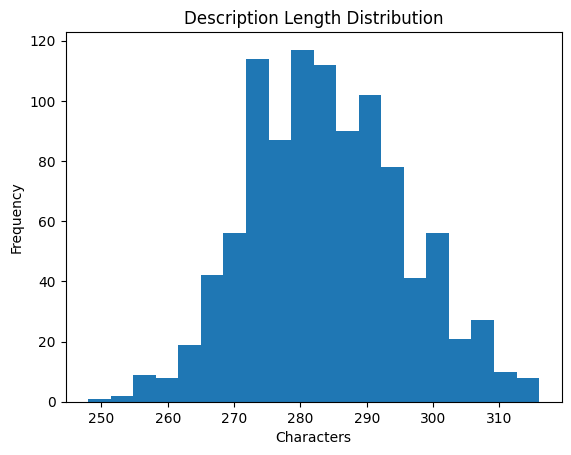

In [14]:
plt.hist(df["description_length"], bins=20)

plt.title("Description Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

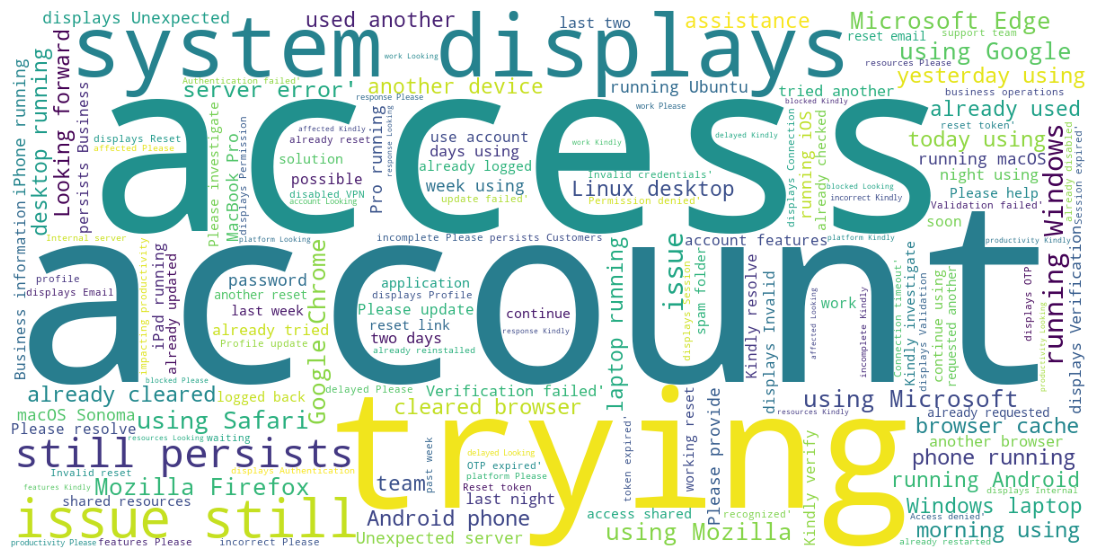

In [15]:
text = " ".join(df["description"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [16]:
df.loc[
    df["description_length"].idxmax(),
    "description"
]

"I have been trying to access my account since for the last two days using Mozilla Firefox on my MacBook Pro running Android 15. The system displays 'Unexpected server error'. I already tried another browser, but the issue still persists. This issue is impacting productivity. Kindly resolve this as soon as possible."

In [17]:
df.loc[
    df["description_length"].idxmin(),
    "description"
]

"I have been trying to access my account since today using Safari on my iPad running iOS 18. The system displays 'Reset token expired'. I already cleared browser cache, but the issue still persists. My work is delayed. Kindly investigate this issue."

In [18]:
print("="*70)

print("EDA REPORT")

print("="*70)

print("Rows:", len(df))

print("Columns:", len(df.columns))

print("Missing Values:", df.isnull().sum().sum())

print("Duplicate Rows:", df.duplicated().sum())

print("Unique Categories:", df["category"].nunique())

print("Average Description Length:",
      round(df["description_length"].mean(),2))

print("="*70)

EDA REPORT
Rows: 1000
Columns: 15
Missing Values: 0
Duplicate Rows: 0
Unique Categories: 3
Average Description Length: 283.95
